In [329]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import collections
from matplotlib.dates import date2num
from pandas.api.types import is_datetime64_any_dtype as is_datetime


PATH = "../data/preemi-30apr2021.dta"

df = pd.read_stata(PATH)

df[df == ""] = np.nan

columns = list(df)

# Unique columns
df = df.drop(columns=["protocolid", "personid", "pr_id", "ch_id", "mt_id"])

# Event status
df = df.drop(columns=[c for c in columns if "eventstatus_e" in c])

# Versions
df = df.drop(columns=[c for c in columns if "versionname_e" in c])

# Constant or almost unique
df = df.drop(columns=["haemounava_e1"])
df = df.drop(columns=["checklist_e1"])
df = df.drop(columns=["matstata_e2"])

# Remove columns with high NaNs
N = df.shape[0]
for col in columns:
    if col not in df: continue
    n = df[df[col].isnull()].shape[0]
    if n/N > 0.5:
        df = df.drop(columns=[col])

# Remove redundant _e

red_cols = collections.defaultdict(list)
for c in list(df.columns):
    x = c.split("_")
    if len(x[-1]) == 2 and x[-1][0] == "e":
        red_cols["_".join(x[:-1])] += ["_".join(x)]

def get_to_drop(v):
    b = -1
    best = None
    for x in v:
        if int(x[-1]) > b:
            b = int(x[-1])
            best = x
    return [x for x in v if x != best]

for k,v in red_cols.items():
    v = get_to_drop(v)
    #df = df.drop(columns=v)

df = df.drop(columns = ["compperson_e5"])

# Minor cleans

df.loc[df["facid_e5"] == "FO3", "facid_e5"] = "F03"
df.loc[df["facid_e5"] == "FO2", "facid_e5"] = "F02"

# Remove dirty variables

df = df.drop(columns=["BWDQ_cat", "birthweightcat1", "gestagecat2", "gestagecat1"])

# Newly realised redundant
df = df.drop(columns = ["facid_e5"])

# Clean data type

def datatype_cleaner(df, col):
    df_ = df.copy()
    df_ = df_[df_[col].notnull()]
    N = df_.shape[0]
    df_["numnew"] = pd.to_numeric(df_[col], errors="coerce")
    df_["datnew"] = pd.to_datetime(df_[col], errors="coerce")
    if df_[df_["numnew"].notnull()].shape[0]/N > 0.8:
        df[col] = pd.to_numeric(df[col])
        return df
    if df_[df_["datnew"].notnull()].shape[0]/N > 0.8:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        df.loc[df[col] < pd.Timestamp(1910,1,1)] = np.nan
        return df
    return df

for col in columns:
    if col not in df: continue
    df = datatype_cleaner(df, col)


df.loc[df["matage"] > 60, "matage"] = np.nan
df.loc[df["eduyrs_e1"] > 15, "eduyrs_e1"] = 15
df.loc[df["matwei_e1"] > 200, "matwei_e1"] = np.nan
df.loc[df["babwght_e2"] > 8000, "babwght_e2"] = np.nan
df.loc[df["bwdat"] == "Birth weight missing", "bwdat"] = np.nan
df.loc[df["fetneo_e2"] == "3=Fresh Stillbirth (No movement", "fetneo_e2"] = "3=Fresh Stillbirth"
df[df == "Unknown"] = np.nan
df[df == "unknown"] = np.nan
df[df == "Don't know"] = np.nan

df["vitalstatus_ltf"] = np.nan
df.loc[df["vitalstatus"] == "LTF", ["vitalstatus_ltf"]] = "LTF"
df.loc[(df["vitalstatus"].notnull()) & (df["vitalstatus"] != "LTF"), ["vitalstatus_ltf"]] = "Live birth or Pregnancy loss"
df.loc[df["vitalstatus"] == "LTF", ["vitalstatus"]] = np.nan

df["pr_outcome_miscarriage"] = np.nan
df.loc[df["pr_outcome"] == "Miscarriage", ["pr_outcome_miscarriage"]] = "Miscarriage"
df.loc[(df["pr_outcome"] != "Miscarriage") & (df["pr_outcome"].notnull()), ["pr_outcome_miscarriage"]] = "No miscarriage"
df["pr_outcome_alive"] = np.nan
df.loc[df["pr_outcome"].isin(["Miscarriage", "Stillbirth"]), ["pr_outcome_alive"]] = "Miscarriage or Stillbirth"
df.loc[df["pr_outcome"] == "Live birth", ["pr_outcome_alive"]] = "Live birth"
df = df.drop(columns=["pr_outcome"])

df.to_csv("df.csv", index=False)
df = pd.read_csv("df.csv")

outcomes = {
    "Miscarriage": ["pr_outcome_miscarriage"],
    "Outcome Death": ["pr_outcome_alive"],
    "Early Neonatal Death": ["infsta_e3"],
    "Late Neonatal Death": ["infsta_e4"],
    "Pre-term Delivery": ["preterm", "babterm_e2"] # babterm_e2 is better according to previous tests
}

gestation = {
    "Gestation": ["g_age", "gestage"], # g_age is in days, gestage in weeks
    "Expected Due Date": ["edd_e1", "estedd_e1"], # edd_e1
    "Last Menstrual Period": ["mensdate_e1"], # integer
    "Delivery Date": ["delidate1_e1", "motconpl_e2"], # I am removing motconpl_e2 value (most of them are 0)
    "Method of Determining Gestation": ["gestmethod"] # Method gestation - missing in the majority of cases: remove
}

counfounders = {
    "Maternal Age": ["matage", "age_cat", "matagecat", "dob_day"], # matage
    "School Level": ["schlev_e1"], # categorical
    "Years of Education": ["eduyrs_e1"], # numeric
    "Parity": ["parity_lbsb", "parity_cat", "parity"], # Number of viable births / best variable here is lbsb, counting the actual number
    "Maternal Height": ["mathei_e1"],
    "Maternal Weight": ["matwei_e1"],
    "Antenatal Visits": ["antcarfreq_e2", "anc_visit"], # integer
    "Delivery By": ["delivby_e2"], # Categorical - nurse is the majority
    "Delivery Place": ["delivwhr_e2", "delivfac_e2", "deplace"], # first is hospital, clinic, home, other...
    "Type of Delivery Place": ["delivfac_e2"],
    "Mode of Delivery": ["detype", "mod_e2"], # cesarean, vaginal
    "Baby Sex": ["sex", "babysex_e2"], # male / female for the baby
    "Multiple Birth": ["multbirth_e2", "multiple"],
    "Birthweight": ["birthweight"],
    "Birthweight Measure": ["bwdat"],
}

neonatal_tx = {
    "Neonatal Antibiotics": ["neotreant_e2"], # 0, 1, 2
    "CPAP": ["neotrecpap_e2"], # 0, 1, 2
    "Oxygen": ["neotreoxy_e2"] # 0, 1, 2
}

interventions = {
    "Antenatal Visits": ["antcarfreq_e2"],
    "Dexamethasone": ["mattredex_e2"], # 0, 1, 2
    "Kangaroo Mother Care": ["neotrekmc_e2"], # 0, 1, 2
    "Cord care Chlorhexidine": ["neotremcc_e2"], # 0, 1, 2
    "Bag and Mask Resuscitation": ["babresbm_e2"],
}

all_variables = dict((k,v[0]) for d in [outcomes, gestation, counfounders, neonatal_tx, interventions] for k,v in d.items())

all_columns = list(set([x for k,v in all_variables.items() for x in [v]]))

dt = df[all_columns]

def is_date_column(df, c):
    if is_datetime(df[df[c].notnull()][c]):
        return True
    else:
        return False

def convert_date_to_num(x):
    try:
        return date2num(x)
    except:
        return np.nan
    
dt = dt.copy()
for c in list(dt.columns):
    if is_date_column(dt, c):
        dt.loc[:, [c]] = [convert_date_to_num(x) for x in list(dt[c])]
        
def binarize_variable(dt, c, t):
    b = c + "_bin"
    dt[b] = np.nan
    dt.loc[dt[c] == t, [b]] = 1
    dt.loc[(dt[c] != t) & (dt[c].notnull()), [b]] = 0
    dt = dt.drop(columns = [c])
    dt = dt.rename(columns={b: c})
    return dt

dt = binarize_variable(dt, "preterm", "Preterm")
dt = binarize_variable(dt, "pr_outcome_miscarriage", "Miscarriage")
dt = binarize_variable(dt, "pr_outcome_alive", "Miscarriage or Stillbirth")
dt = binarize_variable(dt, "infsta_e3", "Dead")
dt = binarize_variable(dt, "infsta_e4", "Dead")

dt = dt.sort_values(by="mensdate_e1").copy()
dt = dt[dt["mensdate_e1"].notnull()].reset_index(drop=True)

variable_stages = {
    "Day0": [
        "Maternal Age",
        "School Level",
        "Years of Education",
        "Parity",
        "Maternal Height",
        "Maternal Weight",
        "Multiple Birth",
    ],
    "Pregnancy": [
        "Antenatal Visits"
    ],
    "PreDelivery": [
        "Method of Determining Gestation",
        "Last Menstrual Period",
        "Delivery Date",
        "Type of Delivery Place",
        "Delivery Place",
        "Delivery By",
        "Mode of Delivery"
    ],
    "PostDelivery": [
        "Birthweight",
        "Birthweight Measure",
        "Method of Determining Gestation",
        "Baby Sex",
        "Dexamethasone",
        "CPAP",
        "Oxygen",
        "Kangaroo Mother Care",
        "Cord care Chlorhexidine",
        "Bag and Mask Resuscitation"
    ],
}

modifiable_variables = {
    "Antenatal Visits",
    "Dexamethasone",
    "CPAP",
    "Oxygen",
    "Kangaroo Mother Care Skin to Skin",
    "Cord care Chlorhexidine",
    "Bag and Mask Resuscitation"
}

import json

with open("../app/variable_stages.json", "w") as f:
    json.dump(variable_stages, f)

with open("../app/modifiable_variables.json", "w") as f:
    json.dump(list(modifiable_variables), f)

with open("../app/all_variables.json", "w") as f:
    json.dump(all_variables, f)

all_categories = collections.defaultdict(list)

for d in [("Outcomes", outcomes), ("Gestation", gestation), ("Counfounders", counfounders), ("Neonatal Treatment", neonatal_tx), ("Interventions", interventions)]:
    for k in d[1].keys():
        all_categories[d[0]] += [k]

In [313]:
# auxiliary 

outcomes = {
    "Miscarriage": ["pr_outcome_miscarriage"],
    "Outcome Death": ["pr_outcome_alive"],
    "Early Neonatal Death": ["infsta_e3"],
    "Late Neonatal Death": ["infsta_e4"],
    "Pre-term Delivery": ["babterm_e2", "preterm"] # babterm_e2 is better according to previous tests
}

In [314]:
from autogluon.tabular import TabularDataset, TabularPredictor

In [221]:
# Predict outcome at birth

In [336]:
dt_ = dt[dt["pr_outcome_alive"].notnull()]
print(dt_[dt_["pr_outcome_alive"] == 1].shape)
dt_ = dt_[dt_["delidate1_e1"].notnull()]
print(dt_[dt_["pr_outcome_alive"] == 1].shape)
dt_ = dt_[dt_["preterm"] == 0]
print(dt_[dt_["pr_outcome_alive"] == 1].shape)
dt_ = dt_.reset_index(drop=True)

all_outcomes = set([v[0] for k, v in outcomes.items()])

target = "pr_outcome_alive"
columns = [c for c in list(dt_.columns) if c not in all_outcomes] + [target]
allowed = [all_variables[k] for k in variable_stages["Day0"]]
allowed += [all_variables[k] for k in variable_stages["Pregnancy"]]
allowed += [all_variables[k] for k in variable_stages["PreDelivery"]]
#allowed += [all_variables[k] for k in ["Last Menstrual Period", "Delivery Date"]]
columns = [c for c in columns if c in allowed + [target]]
#columns = [c for c in columns if "date" not in c]

dt_ = dt_[columns]
dt_ = dt_[dt_[target].notnull()]

print(dt_.shape)
print(dt_)


dt_ = TabularDataset(dt_)

def train_test_split(df, train_size):
    n = df.shape[0]
    train = df.head(int(n*train_size))
    test = df.tail(int(n*(1-train_size)))
    print(train[train[target] == 1].shape[0])
    print(test[test[target] == 1].shape[0])
    return train, test

dt_tr, dt_te = train_test_split(dt_, 0.5)



(182, 32)
(96, 32)
(43, 32)
(3901, 16)
      eduyrs_e1 delivwhr_e2  mathei_e1  matwei_e1  parity_lbsb mensdate_e1  \
0          11.0    Hospital      155.0       55.0          1.0  2014-02-12   
1           7.0    Hospital      175.0       95.0          4.0  2014-10-12   
2           9.0    Hospital      167.0       65.0          2.0  2014-11-18   
3          12.0    Hospital      160.0       59.0          1.0  2015-01-04   
4           9.0    Hospital      161.0       59.0          4.0  2015-01-05   
...         ...         ...        ...        ...          ...         ...   
3896        2.0    Hospital      164.0       62.0          3.0  2016-12-07   
3897        7.0    Hospital      153.0       55.0          3.0  2016-12-07   
3898       11.0    Hospital      157.0       51.0          3.0  2016-12-08   
3899        NaN    Hospital      163.0       63.0          1.0  2016-12-08   
3900       10.0    Hospital      168.0       64.0          2.0  2016-12-08   

     gestmethod         

In [337]:
model = TabularPredictor(label=target, problem_type="binary", eval_metric="roc_auc")
model.fit(dt_tr, presets="best_quality")
model.evaluate(dt_te)

No path specified. Models will be saved in: "AutogluonModels/ag-20220503_101726/"
Presets specified: ['best_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20220503_101726/"
AutoGluon Version:  0.3.1
Train Data Rows:    1950
Train Data Columns: 15
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    24294.72 MB
	Train Data (Original)  Memory Usage: 1.15 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeatureGenerator...
		Fit

{'roc_auc': 0.6418573650299935,
 'accuracy': 0.9892307692307692,
 'balanced_accuracy': 0.5,
 'mcc': 0.0,
 'f1': 0.0,
 'precision': 0.0,
 'recall': 0.0}

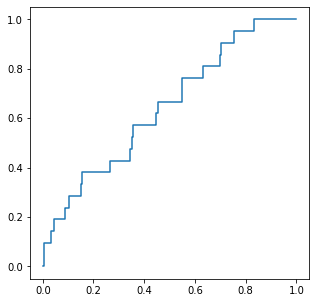

In [338]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(dt_te[target], model.predict_proba(dt_te)[1])

fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.plot(fpr, tpr)

In [335]:
model.feature_importance(dt_te)

Computing feature importance via permutation shuffling for 15 features using 780 rows with 3 shuffle sets...
	121.33s	= Expected runtime (40.44s per shuffle set)
	22.36s	= Actual runtime (Completed 3 of 3 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
delivfac_e2,0.083506,0.035785,0.028055,3,0.288557,-0.121544
eduyrs_e1,0.022035,0.019119,0.092011,3,0.131588,-0.087519
schlev_e1,0.006364,0.004088,0.057221,3,0.029790,-0.017063
detype,0.000996,0.026074,0.476641,3,0.150402,-0.148411
gestmethod,0.000000,0.000000,0.500000,3,0.000000,0.000000
mensdate_e1,-0.000519,0.000344,0.939941,3,0.001449,-0.002488
parity_lbsb,-0.001688,0.018195,0.556458,3,0.102573,-0.105949
delivwhr_e2,-0.008745,0.032556,0.656246,3,0.177805,-0.195294
delivby_e2,-0.010433,0.023807,0.736453,3,0.125985,-0.146850
matage,-0.014156,0.013821,0.890975,3,0.065038,-0.093350


In [275]:
dt_te

,eduyrs_e1,mathei_e1,matwei_e1,parity_lbsb,mensdate_e1,schlev_e1,antcarfreq_e2,delidate1_e1,multbirth_e2,matage,pr_outcome_alive
9551,9.0,167.0,67.0,1.0,2016-05-25,3=School,5.0,2012-05-27,0.0,25.0,0.0
9552,12.0,999.0,68.0,2.0,2016-05-25,3=School,3.0,2008-01-31,0.0,26.0,0.0
9553,9.0,151.0,55.0,1.0,2016-05-25,3=School,4.0,2013-04-02,0.0,20.0,0.0
9555,7.0,152.0,65.0,4.0,2016-05-25,3=School,4.0,2000-10-27,0.0,32.0,0.0
9557,7.0,160.0,88.0,1.0,2016-05-25,3=School,3.0,2015-05-09,0.0,23.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
11256,10.0,168.0,64.0,2.0,2016-12-08,3=School,4.0,2013-04-20,0.0,28.0,0.0
11257,12.0,157.0,53.0,1.0,2016-12-09,3=School,3.0,2013-07-10,0.0,21.0,0.0
11258,8.0,132.0,43.0,1.0,2016-12-09,3=School,2.0,2013-02-07,0.0,23.0,0.0
11261,9.0,154.0,NaN,3.0,2016-12-31,3=School,4.0,2001-09-05,0.0,36.0,0.0


In [215]:
dt_ = dt[dt["pr_outcome_alive"] == 0]

all_outcomes = set([v[0] for k, v in outcomes.items()])

target = "infsta_e4"
columns = [c for c in list(dt_.columns) if c not in all_outcomes] + [target]

dt_ = dt_[columns]
dt_ = dt_[dt_[target].notnull()]

132
50


Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20220502_215403/"
AutoGluon Version:  0.3.1
Train Data Rows:    8752
Train Data Columns: 27
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    26697.53 MB
	Train Data (Original)  Memory Usage: 6.92 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeatureGenerator...
		Fitting DatetimeFeatureGenerator...

In [228]:
model.evaluate(dt_te)

Evaluation: roc_auc on test data: 0.9539943872778297
Evaluations on test data:
{
    "roc_auc": 0.9539943872778297,
    "accuracy": 0.9803473491773309,
    "balanced_accuracy": 0.5700000000000001,
    "mcc": 0.37045890225189615,
    "f1": 0.24561403508771928,
    "precision": 1.0,
    "recall": 0.14
}


{'roc_auc': 0.9539943872778297,
 'accuracy': 0.9803473491773309,
 'balanced_accuracy': 0.5700000000000001,
 'mcc': 0.37045890225189615,
 'f1': 0.24561403508771928,
 'precision': 1.0,
 'recall': 0.14}

In [165]:
dt_[dt_["mensdate_e1"].notnull()].shape

(10611, 27)